# Top 100 UK groups: population-adjusted origin analysis

This companion keeps the original popularity-first concentration analysis and
adds a population denominator. It asks:

> Relative to the size of an origin's Functional Urban Area, how much of this
> frozen top 100 did the area produce?

This is an **output-per-population sensitivity analysis**, not a scene-depth
ranking. A city can rank highly because one globally dominant band clears the
top-100 cutoff.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "reference/uk_fua_top20_2021.csv").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Could not locate the uk-music-cities repository root")

SNAPSHOT_ID = "20260718T204522Z"
BANDS_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_bands.csv"
ORIGINS_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_origins.csv"
MAPPING_AUDIT_PATH = ROOT / "data/interim/popularity_first_top100_20260718T204522Z_fua_mapping_audit.csv"
STRICT_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_population_strict.csv"
EXTENDED_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_population_extended.csv"
REPORT_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_population_adjusted_report.json"
ARTIFACT_DIR = ROOT / "artifacts/top100_popularity_first_population_adjusted/20260718T204522Z"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

bands = pd.read_csv(BANDS_PATH, keep_default_na=False)
origins = pd.read_csv(ORIGINS_PATH, keep_default_na=False)
mapping_audit = pd.read_csv(MAPPING_AUDIT_PATH, keep_default_na=False)
strict = pd.read_csv(STRICT_PATH, keep_default_na=False)
extended = pd.read_csv(EXTENDED_PATH, keep_default_na=False)
report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))

assert len(bands) == 100
assert bands["returned_spotify_id"].nunique() == 100
assert origins["band_count"].sum() == 100
assert len(mapping_audit) == 100
assert strict["fua_code"].nunique() == len(strict)
assert (strict["population"] > 0).all()
assert (
    strict["top100_monthly_listeners_per_resident"]
    .sort_values(ascending=False)
    .tolist()
    == strict["top100_monthly_listeners_per_resident"].tolist()
)

captured_at = bands["stats_extracted_at_utc"].iloc[0]
strict_coverage = report["strict_mapping"]
extended_coverage = report["extended_mapping_sensitivity"]
display(Markdown(
    f"**Frozen Spotify snapshot:** `{SNAPSHOT_ID}` ({captured_at}) · "
    f"**Population:** OECD/EU FUA, {report['population_year']} · "
    f"**Strict mapping:** {strict_coverage['mapped_bands']}/100 bands "
    f"({strict_coverage['mapped_listener_reach_share']:.1%} of reach)"
))

**Frozen Spotify snapshot:** `20260718T204522Z` (2026-07-18T20:45:22.974241+00:00) · **Population:** OECD/EU FUA, 2021 · **Strict mapping:** 87/100 bands (89.0% of reach)

## 01. What changes when population enters the denominator?

The original analysis measures concentration inside a popularity-selected
sample. This companion retains that result, then calculates two rates:

- **Top-100 bands per million residents** = selected band count ÷ 2021 FUA
  population × 1,000,000.
- **Top-100 monthly listeners per resident** = the selected bands' captured
  global monthly listeners ÷ 2021 FUA population.

"Listeners per resident" is a normalization ratio. It is **not** the share of
local residents listening, so it can exceed one. The numerator is global
Spotify reach; only the denominator is local.

In [2]:
lineage = pd.DataFrame(
    [
        {
            "stage": "Popularity selection",
            "frozen input": report["inputs"]["bands"],
            "role": "The same reviewed top 100 as the original analysis",
        },
        {
            "stage": "Raw origin concentration",
            "frozen input": report["inputs"]["origins"],
            "role": "Unadjusted count and listener-share baseline",
        },
        {
            "stage": "Origin → FUA decisions",
            "frozen input": report["inputs"]["mapping"],
            "role": "Strict assignments, sensitivity assignments, exclusions",
        },
        {
            "stage": "Population denominator",
            "frozen input": report["inputs"]["population"],
            "role": "2021 OECD/EU Functional Urban Area population",
        },
    ]
)
display(lineage.style.hide(axis="index"))

stage,frozen input,role
Popularity selection,data/processed/popularity_first_top100_20260718T204522Z_bands.csv,The same reviewed top 100 as the original analysis
Raw origin concentration,data/processed/popularity_first_top100_20260718T204522Z_origins.csv,Unadjusted count and listener-share baseline
Origin → FUA decisions,reference/popularity_first_origin_fua_mapping_20260718.csv,"Strict assignments, sensitivity assignments, exclusions"
Population denominator,data/processed/uk_fua_population_2021_20260718T201304Z.csv,2021 OECD/EU Functional Urban Area population


## 02. Keep the raw result visible

Population adjustment answers a different question, so the raw geographic
concentration is not discarded. London still supplies the largest number of
bands in the selected 100.

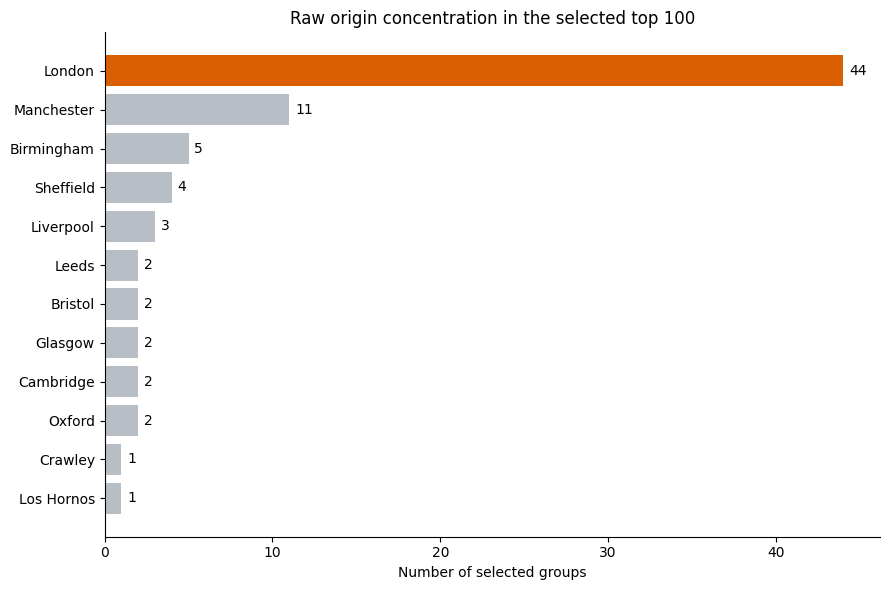

origin_cluster,band_count,monthly_listeners_total,band_share,listener_share
London,44,"802,923,815",44.0%,49.5%
Manchester,11,"165,910,277",11.0%,10.2%
Birmingham,5,"56,059,884",5.0%,3.5%
Sheffield,4,"82,887,435",4.0%,5.1%
Liverpool,3,"50,053,015",3.0%,3.1%
Oxford,2,"70,261,364",2.0%,4.3%
Cambridge,2,"41,124,400",2.0%,2.5%
Glasgow,2,"20,436,452",2.0%,1.3%
Bristol,2,"14,651,842",2.0%,0.9%
Leeds,2,"13,877,184",2.0%,0.9%


In [3]:
origin_top = origins.head(12).sort_values("band_count")
fig, ax = plt.subplots(figsize=(9, 6))
colors = [
    "#d95f02" if origin == "London" else "#b8bec6"
    for origin in origin_top["origin_cluster"]
]
ax.barh(origin_top["origin_cluster"], origin_top["band_count"], color=colors)
ax.set(
    title="Raw origin concentration in the selected top 100",
    xlabel="Number of selected groups",
    ylabel="",
)
ax.spines[["top", "right"]].set_visible(False)
for y, value in enumerate(origin_top["band_count"]):
    ax.text(value + 0.35, y, f"{int(value)}", va="center")
fig.tight_layout()
path = ARTIFACT_DIR / "01_raw_origin_counts.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

display(
    origins.head(15).style
    .hide(axis="index")
    .format(
        {
            "monthly_listeners_total": "{:,.0f}",
            "band_share": "{:.1%}",
            "listener_share": "{:.1%}",
        }
    )
)

## 03. Denominator coverage

The main result uses only exact FUA label matches and three transparent label
aliases: Bath, Brighton and Dundee. It does not silently force every formation
place into the nearest large city.

In [4]:
coverage = pd.DataFrame(
    [
        {
            "view": "Strict (main)",
            "mapped bands": strict_coverage["mapped_bands"],
            "band coverage": strict_coverage["mapped_band_share"],
            "listener-reach coverage": strict_coverage["mapped_listener_reach_share"],
            "mapped FUAs": strict_coverage["mapped_fuas"],
        },
        {
            "view": "Extended (sensitivity)",
            "mapped bands": extended_coverage["mapped_bands"],
            "band coverage": extended_coverage["mapped_band_share"],
            "listener-reach coverage": extended_coverage["mapped_listener_reach_share"],
            "mapped FUAs": extended_coverage["mapped_fuas"],
        },
    ]
)
display(
    coverage.style
    .hide(axis="index")
    .format(
        {
            "band coverage": "{:.1%}",
            "listener-reach coverage": "{:.1%}",
        }
    )
)

strict_exclusions = mapping_audit.loc[
    mapping_audit["mapping_tier"].ne("strict"),
    [
        "spotify_name",
        "origin_cluster",
        "monthly_listeners",
        "mapping_tier",
        "study_city_label",
        "notes",
    ],
].sort_values("monthly_listeners", ascending=False)
display(Markdown("**Bands excluded from the strict denominator view**"))
display(
    strict_exclusions.style
    .hide(axis="index")
    .format({"monthly_listeners": "{:,.0f}"})
)

view,mapped bands,band coverage,listener-reach coverage,mapped FUAs
Strict (main),87,87.0%,89.0%,20
Extended (sensitivity),94,94.0%,94.7%,24


**Bands excluded from the strict denominator view**

spotify_name,origin_cluster,monthly_listeners,mapping_tier,study_city_label,notes
Bee Gees,Los Hornos,"29,286,539",excluded_non_uk,,Reported formation place is outside the United Kingdom.
Disclosure,Reigate,"25,360,907",excluded_no_defensible_fua,,No assignment is made without an official locality-to-FUA crosswalk.
Keane,Battle,"23,259,577",reviewed_extended,Hastings,Included only in the extended sensitivity view as a reviewed association with Hastings FUA.
Muse,Teignmouth,"20,942,571",reviewed_extended,Exeter,Included only in the extended sensitivity view as a reviewed association with Exeter FUA.
Depeche Mode,Basildon,"17,667,155",reviewed_extended,London,Included only in the extended sensitivity view as a reviewed association with London FUA.
Two Door Cinema Club,Bangor,"9,884,423",reviewed_extended,Belfast,Included only in the extended sensitivity view as a reviewed association with Belfast FUA.
Seafret,Bridlington,"9,520,023",excluded_no_defensible_fua,,No assignment is made without an official locality-to-FUA crosswalk.
Genesis,Godalming,"9,434,858",reviewed_extended,Guildford,Included only in the extended sensitivity view as a reviewed association with Guildford FUA.
The Proclaimers,Auchtermuchty,"8,100,195",excluded_no_defensible_fua,,No assignment is made without an official locality-to-FUA crosswalk.
Deep Purple,Hertford,"6,998,809",excluded_no_defensible_fua,,No assignment is made without an official locality-to-FUA crosswalk.


## 04. Main result: captured reach per resident

Every strict-mapped FUA remains in the result. Bars supported by two or more
bands are coloured; one-band results are grey and explicitly labelled.

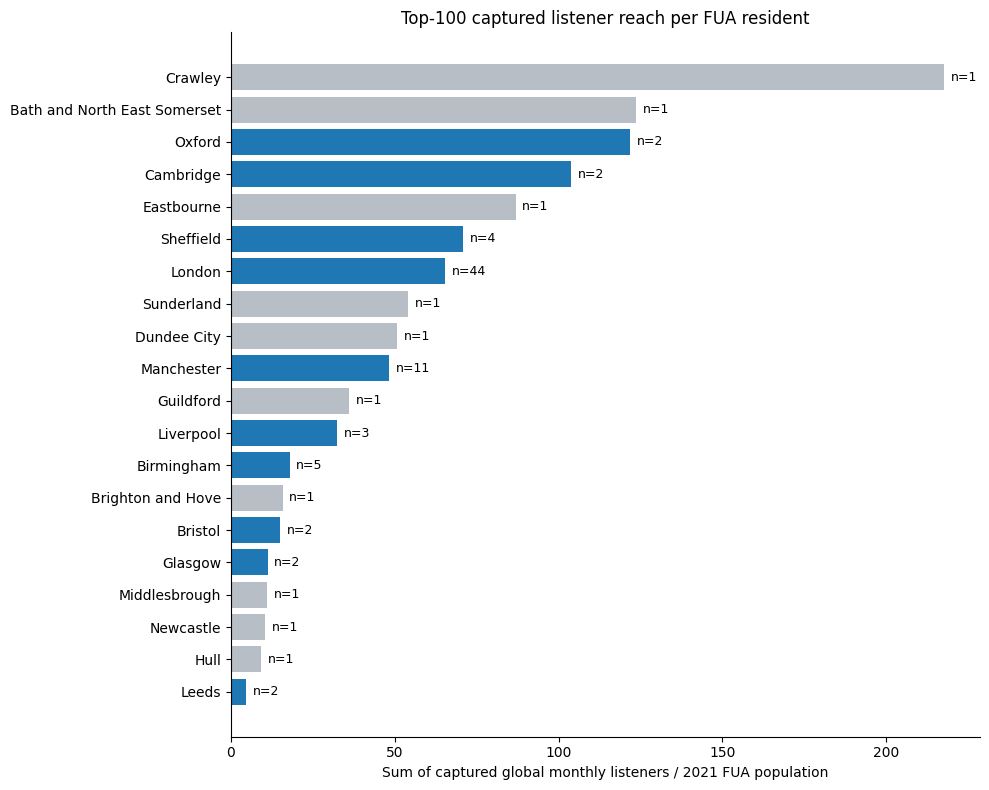

*Blue: at least two selected bands. Grey: one selected band. n is the selected-band count behind the rate.*

rank,FUA,selected bands,population,captured listeners,listeners / resident,bands / million
1,Crawley,1,"118,607","25,827,890",217.76,8.43
2,Bath and North East Somerset,1,"192,419","23,781,006",123.59,5.20
3,Oxford,2,"576,725","70,261,364",121.83,3.47
4,Cambridge,2,"396,189","41,124,400",103.80,5.05
5,Eastbourne,1,"101,601","8,829,850",86.91,9.84
6,Sheffield,4,"1,168,389","82,887,435",70.94,3.42
7,London,44,"12,274,097","802,923,815",65.42,3.58
8,Sunderland,1,"274,378","14,843,560",54.10,3.64
9,Dundee City,1,"261,740","13,274,460",50.72,3.82
10,Manchester,11,"3,432,092","165,910,277",48.34,3.21


In [5]:
plot_strict = strict.head(20).sort_values(
    "top100_monthly_listeners_per_resident"
)
fig, ax = plt.subplots(figsize=(10, 8))
colors = [
    "#1f77b4" if count >= 2 else "#b8bec6"
    for count in plot_strict["band_count"]
]
ax.barh(
    plot_strict["study_city_label"],
    plot_strict["top100_monthly_listeners_per_resident"],
    color=colors,
)
ax.set(
    title="Top-100 captured listener reach per FUA resident",
    xlabel="Sum of captured global monthly listeners / 2021 FUA population",
    ylabel="",
)
ax.spines[["top", "right"]].set_visible(False)
for y, (_, row) in enumerate(plot_strict.iterrows()):
    ax.text(
        row["top100_monthly_listeners_per_resident"] + 2,
        y,
        f"n={int(row['band_count'])}",
        va="center",
        fontsize=9,
    )
fig.tight_layout()
path = ARTIFACT_DIR / "02_population_adjusted_all_fuas.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()
display(Markdown(
    "*Blue: at least two selected bands. Grey: one selected band. "
    "n is the selected-band count behind the rate.*"
))

strict_table = strict[
    [
        "rank_by_listener_reach_per_resident",
        "study_city_label",
        "band_count",
        "population",
        "monthly_listeners_total",
        "top100_monthly_listeners_per_resident",
        "top100_bands_per_million_residents",
    ]
].rename(
    columns={
        "rank_by_listener_reach_per_resident": "rank",
        "study_city_label": "FUA",
        "band_count": "selected bands",
        "monthly_listeners_total": "captured listeners",
        "top100_monthly_listeners_per_resident": "listeners / resident",
        "top100_bands_per_million_residents": "bands / million",
    }
)
display(
    strict_table.style
    .hide(axis="index")
    .format(
        {
            "population": "{:,.0f}",
            "captured listeners": "{:,.0f}",
            "listeners / resident": "{:.2f}",
            "bands / million": "{:.2f}",
        }
    )
)

## 05. Stability view: require at least two selected bands

The full ranking above is the main result. This diagnostic removes no
observations from the calculations; it simply focuses the display on FUAs whose
rate is not determined by a single band.

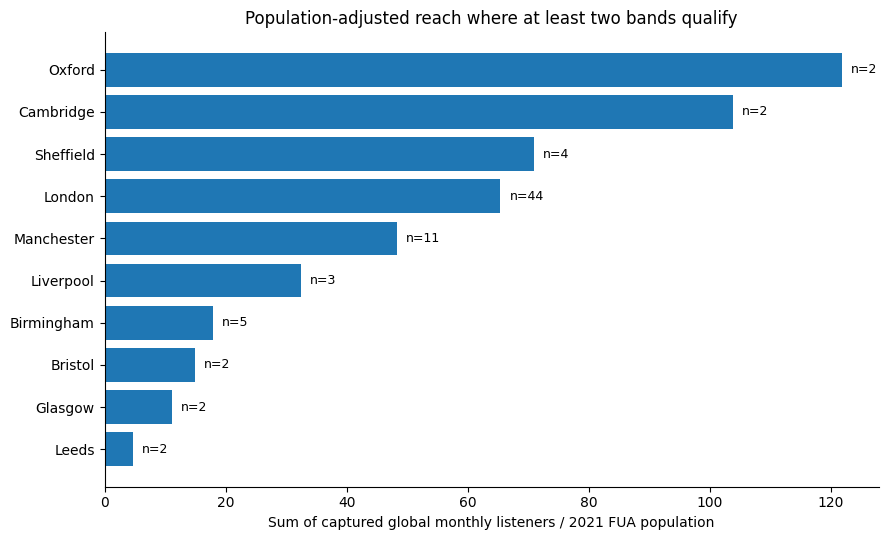

In [6]:
stable = (
    strict.loc[strict["band_count"].ge(2)]
    .sort_values("top100_monthly_listeners_per_resident")
)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(
    stable["study_city_label"],
    stable["top100_monthly_listeners_per_resident"],
    color="#1f77b4",
)
ax.set(
    title="Population-adjusted reach where at least two bands qualify",
    xlabel="Sum of captured global monthly listeners / 2021 FUA population",
    ylabel="",
)
ax.spines[["top", "right"]].set_visible(False)
for y, (_, row) in enumerate(stable.iterrows()):
    ax.text(
        row["top100_monthly_listeners_per_resident"] + 1.5,
        y,
        f"n={int(row['band_count'])}",
        va="center",
        fontsize=9,
    )
fig.tight_layout()
path = ARTIFACT_DIR / "03_population_adjusted_minimum_two_bands.png"
fig.savefig(path, dpi=180, bbox_inches="tight")
plt.show()

In [7]:
top_fua = strict.iloc[0]
top_fua_bands = mapping_audit.loc[
    mapping_audit["fua_code"].eq(top_fua["fua_code"])
    & mapping_audit["mapping_tier"].eq("strict"),
    "spotify_name",
].tolist()
stable_ranked = (
    strict.loc[strict["band_count"].ge(2)]
    .sort_values("rank_by_listener_reach_per_resident")
)
stable_names = stable_ranked.head(5)["study_city_label"].tolist()

display(Markdown(
    f"""## 06. Interpretation

- **{top_fua['study_city_label']} ranks first in the complete strict view**, but
  its rate is based on one band: **{', '.join(top_fua_bands)}**. That is a
  superstar result, not evidence of broad scene depth.
- Among FUAs represented by at least two selected bands, the first five are
  **{', '.join(stable_names)}**.
- London’s raw scale remains exceptional, but its much larger population moves
  it below several smaller FUAs after normalization.
- The two rates describe representation within this particular top 100. They
  should not be read as estimates of all musical output or local listening.
"""
))

## 06. Interpretation

- **Crawley ranks first in the complete strict view**, but
  its rate is based on one band: **The Cure**. That is a
  superstar result, not evidence of broad scene depth.
- Among FUAs represented by at least two selected bands, the first five are
  **Oxford, Cambridge, Sheffield, London, Manchester**.
- London’s raw scale remains exceptional, but its much larger population moves
  it below several smaller FUAs after normalization.
- The two rates describe representation within this particular top 100. They
  should not be read as estimates of all musical output or local listening.


## 07. Extended mapping sensitivity

The extended view adds seven reviewed associations for places that do not match
an FUA label directly. These are deliberately treated as sensitivity
assignments, not official boundary facts.

In [8]:
comparison = strict[
    [
        "fua_code",
        "study_city_label",
        "band_count",
        "top100_monthly_listeners_per_resident",
        "rank_by_listener_reach_per_resident",
    ]
].merge(
    extended[
        [
            "fua_code",
            "study_city_label",
            "band_count",
            "top100_monthly_listeners_per_resident",
            "rank_by_listener_reach_per_resident",
        ]
    ],
    on=["fua_code", "study_city_label"],
    how="outer",
    suffixes=("_strict", "_extended"),
)
comparison["band_count_change"] = (
    comparison["band_count_extended"].fillna(0)
    - comparison["band_count_strict"].fillna(0)
)
comparison["rank_change"] = (
    comparison["rank_by_listener_reach_per_resident_strict"]
    - comparison["rank_by_listener_reach_per_resident_extended"]
)
changed = comparison.loc[
    comparison["band_count_change"].ne(0)
    | comparison["rank_change"].fillna(0).ne(0)
].sort_values(
    "rank_by_listener_reach_per_resident_extended",
    na_position="last",
)
display(
    changed.style
    .hide(axis="index")
    .format(
        {
            "band_count_strict": "{:.0f}",
            "band_count_extended": "{:.0f}",
            "top100_monthly_listeners_per_resident_strict": "{:.2f}",
            "top100_monthly_listeners_per_resident_extended": "{:.2f}",
            "rank_by_listener_reach_per_resident_strict": "{:.0f}",
            "rank_by_listener_reach_per_resident_extended": "{:.0f}",
            "band_count_change": "{:+.0f}",
            "rank_change": "{:+.0f}",
        },
        na_rep="—",
    )
)

fua_code,study_city_label,band_count_strict,top100_monthly_listeners_per_resident_strict,rank_by_listener_reach_per_resident_strict,band_count_extended,top100_monthly_listeners_per_resident_extended,rank_by_listener_reach_per_resident_extended,band_count_change,rank_change
UK056F,Hastings,—,—,—,1,126.15,2,+1,—
UK031F,Bath and North East Somerset,1,123.59,2,1,123.59,3,+0,-1
UK560F,Oxford,2,121.83,3,2,121.83,4,+0,-1
UK017F,Cambridge,2,103.80,4,2,103.80,5,+0,-1
UK055F,Eastbourne,1,86.91,5,1,86.91,6,+0,-1
UK010F,Sheffield,4,70.94,6,4,70.94,7,+0,-1
UK033F,Guildford,1,36.05,11,2,70.62,8,+1,+3
UK001F,London,44,65.42,7,45,66.86,9,+1,-2
UK510F,Sunderland,1,54.10,8,1,54.10,10,+0,-2
UK550F,Dundee City,1,50.72,9,1,50.72,11,+0,-2


## 08. Conclusion and limitations

Population adjustment is useful here, but it changes the estimand. The raw
view answers where the selected top 100 came from; the adjusted view answers
how much representation and captured global reach those selected bands account
for relative to FUA population.

Crawley, Bath and Eastbourne show the superstar problem clearly: each rises
sharply on one qualifying band. For a more
scene-like reading, the at-least-two-band diagnostic is more stable, but it is
still conditional on a popularity-selected top 100.

Remaining limitations:

- The top-100 frame inherits Wikidata coverage, identity decisions and a
  volatile Spotify snapshot.
- Thirteen bands are outside the strict denominator view. Six remain unmapped
  even after the extended review.
- Origin-to-FUA assignment is a boundary problem; the strict and extended
  results are separated so that judgment remains visible.
- FUA population is 2021 population; Spotify reach is captured in 2026.
- A deeper city-scene study needs a balanced catalogue per city. That remains
  the purpose of the separate city-first analysis.